# Pretraitement et amelioration du contraste

## Description

Le pretraitement prepare les images avant la segmentation et Lucas-Kanade. La conversion en niveaux de gris permet de travailler sur la luminance. Le filtrage gaussien reduit le bruit local. L'amelioration du contraste rend la voiture plus distincte par rapport a la route et facilite les etapes suivantes.


Frames chargees: 1661
Bbox manuelle utilisee dans les notebooks: (535, 300, 220, 105)


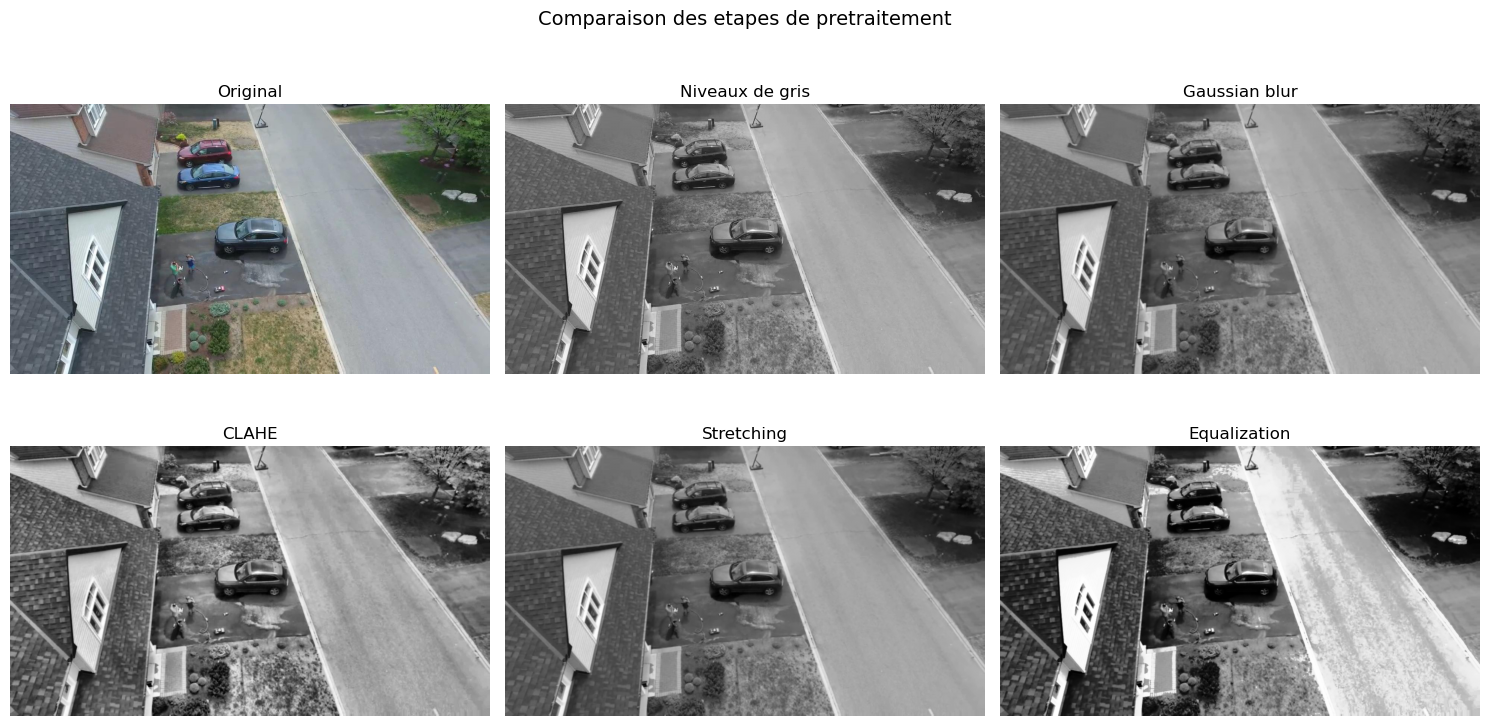

Figure sauvegardee: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project\results\preprocessing\preprocessing_comparison.png


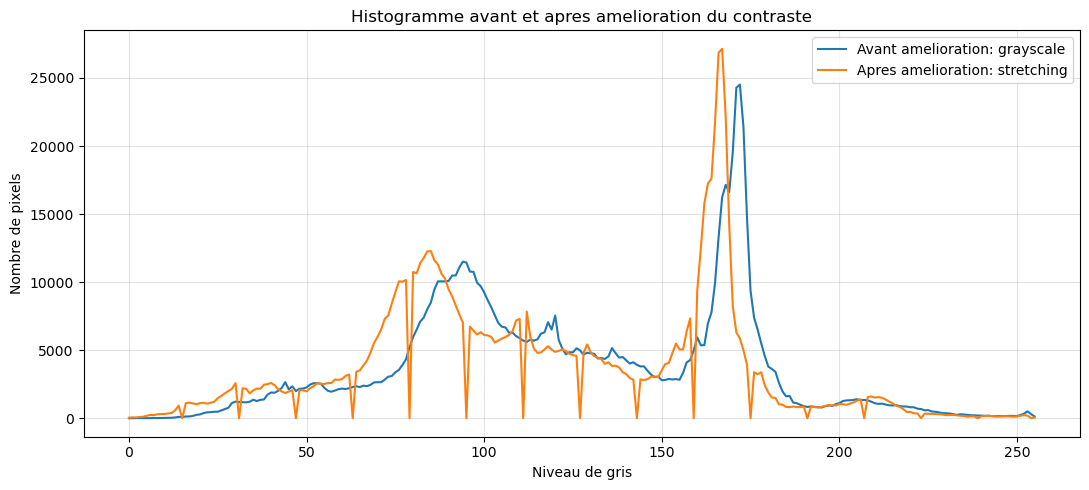

Histogramme sauvegarde: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project\results\histogram\histogram_before_after.png


In [1]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_DIR = PROJECT_ROOT / "data" / "car" / "car-11" / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

image_files = sorted([p for p in DATASET_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}])
if not image_files:
    raise RuntimeError("Aucune image trouvee dans data/car/car-11/img/.")

initial_bbox = (535, 300, 220, 105)  # bbox manuelle: x, y, w, h

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def show_bgr(image, title, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr_to_rgb(image))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(image, title, figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_saved_image(path, title=None, figsize=(12, 6), is_gray=False):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE if is_gray else cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"Image illisible: {path}")
    if is_gray:
        show_gray(image, title or path.name, figsize=figsize)
    else:
        show_bgr(image, title or path.name, figsize=figsize)
    return image

def save_bgr(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def save_gray(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

print(f"Frames chargees: {len(image_files)}")
print(f"Bbox manuelle utilisee dans les notebooks: {initial_bbox}")

from src.preprocessing import compare_preprocessing_methods, compute_histogram, preprocess_image_with_method

preprocessing_dir = ensure_dir(RESULTS_DIR / "preprocessing")
histogram_dir = ensure_dir(RESULTS_DIR / "histogram")
frame = cv2.imread(str(image_files[0]))
methods = compare_preprocessing_methods(frame)
processed = preprocess_image_with_method(frame, method="stretching")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
items = [("Original", frame), ("Niveaux de gris", methods["gray"]), ("Gaussian blur", methods["gaussian"]), ("CLAHE", methods["clahe"]), ("Stretching", methods["stretching"]), ("Equalization", methods["equalization"])]
for ax, (title, image) in zip(axes, items):
    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(bgr_to_rgb(image))
    ax.set_title(title)
    ax.axis("off")
fig.suptitle("Comparaison des etapes de pretraitement", fontsize=14)
fig.tight_layout()
comparison_path = preprocessing_dir / "preprocessing_comparison.png"
fig.savefig(comparison_path, dpi=150)
plt.show()
print("Figure sauvegardee:", comparison_path)

plt.figure(figsize=(11, 5))
plt.plot(compute_histogram(methods["gray"]), label="Avant amelioration: grayscale")
plt.plot(compute_histogram(methods["stretching"]), label="Apres amelioration: stretching")
plt.title("Histogramme avant et apres amelioration du contraste")
plt.xlabel("Niveau de gris")
plt.ylabel("Nombre de pixels")
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
hist_path = histogram_dir / "histogram_before_after.png"
plt.savefig(hist_path, dpi=150)
plt.show()
print("Histogramme sauvegarde:", hist_path)


## Interpretation

Le flou gaussien reduit les petites variations de bruit, tandis que le stretching occupe mieux la dynamique des niveaux de gris. La voiture devient plus lisible par rapport a la route, ce qui aide la segmentation dans la ROI. Une amelioration trop agressive, comme certaines egalisations, peut toutefois modifier fortement les intensites et perturber l'hypothese d'illumination constante du flot optique.


## Resume de l'etape

Cette etape a affiche et sauvegarde les variantes de pretraitement ainsi que les histogrammes avant/apres amelioration. L'image pretraitee avec stretching est retenue comme entree stable pour la segmentation, Canny, la difference d'images et Lucas-Kanade.
